# NYC Sinkhole Risk — Exploratory Data Analysis (v2)
**Datasets:** Pre-cleaned CSVs from `cleaned_datasets/`  
**Goal:** Spatial distribution of cave-in incidents, risk heatmaps, and feature importance via spatial block CV.

## 0. Install Dependencies

In [ ]:
%pip install pandas geopandas folium matplotlib seaborn scipy shapely scikit-learn

## 1. Imports

In [1]:
import re, warnings
import numpy as np
import pandas as pd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print('All imports OK')

All imports OK


## 2. Load Cleaned Datasets

In [2]:
df_311 = pd.read_csv('cleaned_datasets/cave_ins_311.csv', parse_dates=['created_date'])
print(f'311 cave-ins: {len(df_311):,}')
print(f'Date range:   {df_311.created_date.min()} -> {df_311.created_date.max()}')
df_311.head(3)

311 cave-ins: 49,191
Date range:   2020-01-01 10:49:39 -> 2025-11-30 20:07:37


,created_date,complaint_type,descriptor,borough,latitude,longitude,year,month,year_month
0,2025-11-30 20:07:37,Street Condition,Cave-in,QUEENS,40.772045,-73.932017,2025,11,2025-11
1,2025-11-30 17:24:21,Street Condition,Cave-in,STATEN ISLAND,40.599410,-74.062953,2025,11,2025-11
2,2025-11-30 16:38:35,Street Condition,Cave-in,MANHATTAN,40.779124,-73.984976,2025,11,2025-11


In [3]:
df_bedrock = pd.read_csv('cleaned_datasets/bedrock_depth.csv')
print(f'Bedrock points: {len(df_bedrock):,}')
print(f'Depth range:    {df_bedrock.depth_ft.min():.1f} - {df_bedrock.depth_ft.max():.1f} ft')
df_bedrock.head(3)

Bedrock points: 292
Depth range:    0.0 - 1541.2 ft


,fid,source,data_type,elev_ft,depth_ft,latitude,longitude
0,264,Map or Cross-Section,Water/Monitoring Well,58.2790,42.0,40.915556,-73.909722
1,265,Map or Cross-Section,Water/Monitoring Well,191.9300,50.0,40.918889,-73.866111
2,266,Map or Cross-Section,Water/Monitoring Well,34.7776,9.0,40.894444,-73.791111


In [4]:
df_wmb = pd.read_csv('cleaned_datasets/water_main_breaks.csv', parse_dates=['created_date'])
df_wmb_bronx = df_wmb[df_wmb['borough'] == 'BRONX'].copy()
print(f'Water main breaks (all NYC): {len(df_wmb):,}')
print(f'Water main breaks (Bronx):   {len(df_wmb_bronx):,}')
df_wmb_bronx.head(3)

Water main breaks (all NYC): 24,220
Water main breaks (Bronx):   2,384


,created_date,address,borough,status,latitude,longitude
11,2026-03-26 13:56:00,327 BRYANT AVENUE,BRONX,Open,40.807603,-73.883731
15,2026-03-26 12:10:00,2200 WHITE PLAINS ROAD,BRONX,Closed,40.857896,-73.867571
54,2026-03-25 09:27:00,NaN,BRONX,Assigned,40.820822,-73.915611


In [5]:
df_pave = pd.read_csv('cleaned_datasets/pavement_ratings.csv')
df_pave_bronx = df_pave[df_pave['borough'].str.upper() == 'BRONX'].copy()
print(f'Pavement segments (all NYC): {len(df_pave):,}')
print(f'Pavement segments (Bronx):   {len(df_pave_bronx):,}')
print(f'Rating range: {df_pave_bronx.system_rating.min():.1f} - {df_pave_bronx.system_rating.max():.1f}')
df_pave_bronx.head(3)

Pavement segments (all NYC): 488,228
Pavement segments (Bronx):   68,656
Rating range: 0.0 - 10.0


,borough,street_name,road_type,system_rating,inspection_date,latitude,longitude
8858,Bronx,BROADWAY,NaN,9.93,05/04/2024 12:00:00 AM,40.876172,-73.907646
31923,Bronx,ARNOW AVENUE,NaN,8.86,06/13/2018 12:00:00 AM,40.867564,-73.849517
31924,Bronx,ARNOW AVENUE,NaN,5.91,10/01/2018 12:00:00 AM,40.867583,-73.850473


## 3. Basic Stats

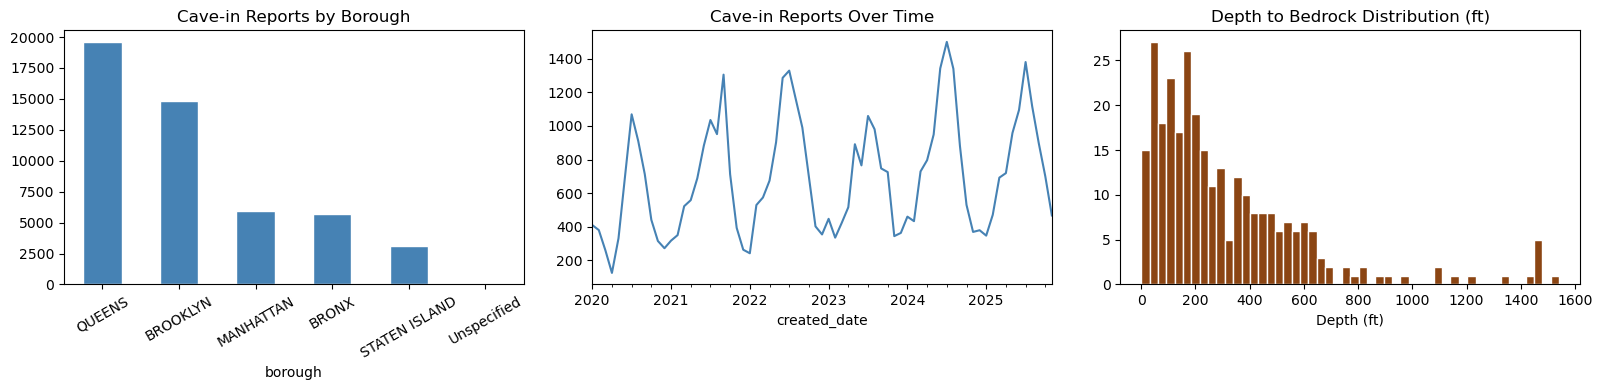

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_311['borough'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Cave-in Reports by Borough')
axes[0].tick_params(axis='x', rotation=30)

df_311.set_index('created_date').resample('ME').size().plot(ax=axes[1], color='steelblue')
axes[1].set_title('Cave-in Reports Over Time')

axes[2].hist(df_bedrock['depth_ft'], bins=50, color='saddlebrown', edgecolor='white')
axes[2].set_title('Depth to Bedrock Distribution (ft)')
axes[2].set_xlabel('Depth (ft)')

plt.tight_layout()
plt.show()

## 4. Spatial Join — Nearest Bedrock Depth to Each Cave-in

In [7]:
bedrock_coords = np.radians(df_bedrock[['latitude', 'longitude']].values)
tree = cKDTree(bedrock_coords)
cave_coords = np.radians(df_311[['latitude', 'longitude']].values)
distances, indices = tree.query(cave_coords, k=1)

df_311 = df_311.copy()
df_311['nearest_bedrock_depth_ft'] = df_bedrock['depth_ft'].iloc[indices].values
df_311['nearest_bedrock_dist_m']   = distances * 6371000
df_311['nearest_bedrock_depth_ft'] = df_311['nearest_bedrock_depth_ft'].where(
    df_311['nearest_bedrock_dist_m'] < 2000, other=np.nan
)
matched = df_311['nearest_bedrock_depth_ft'].notna().sum()
print(f'{matched:,} of {len(df_311):,} cave-in points matched within 2km')

34,461 of 49,191 cave-in points matched within 2km


## 5. Correlation: Cave-in Density vs Bedrock Depth

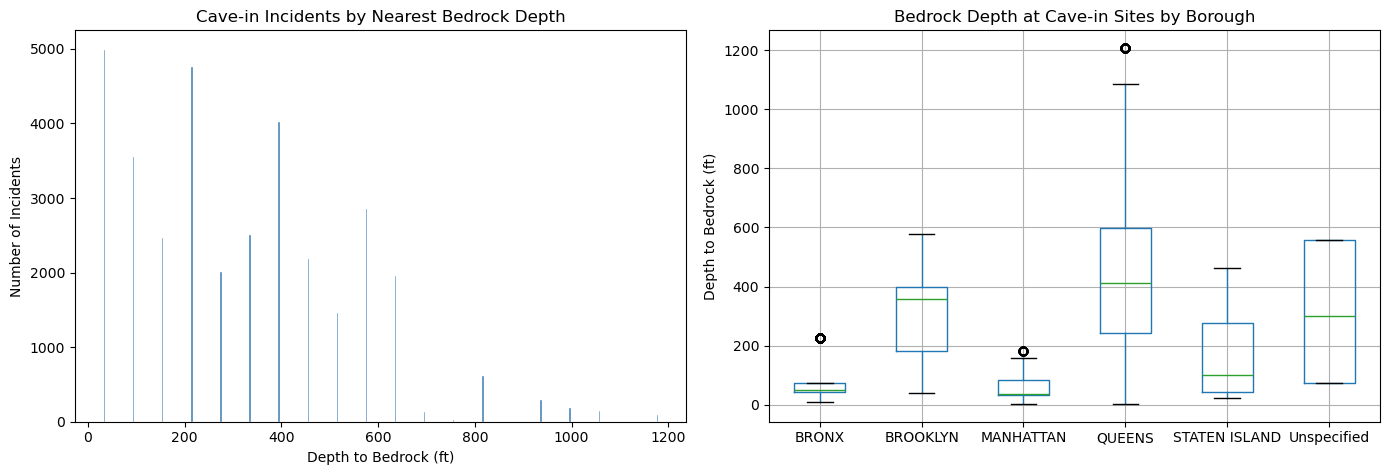

Mean bedrock depth at cave-in sites:   319.0 ft
Median bedrock depth at cave-in sites: 284.9 ft


In [8]:
df_matched = df_311.dropna(subset=['nearest_bedrock_depth_ft'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = pd.cut(df_matched['nearest_bedrock_depth_ft'], bins=20)
bin_counts = df_matched.groupby(bins, observed=True).size().reset_index(name='count')
bin_counts['depth_mid'] = bin_counts['nearest_bedrock_depth_ft'].apply(lambda x: x.mid)
axes[0].bar(bin_counts['depth_mid'].astype(float), bin_counts['count'], width=5, color='steelblue', edgecolor='white')
axes[0].set_title('Cave-in Incidents by Nearest Bedrock Depth')
axes[0].set_xlabel('Depth to Bedrock (ft)')
axes[0].set_ylabel('Number of Incidents')

df_matched.boxplot(column='nearest_bedrock_depth_ft', by='borough', ax=axes[1])
axes[1].set_title('Bedrock Depth at Cave-in Sites by Borough')
axes[1].set_xlabel('')
axes[1].set_ylabel('Depth to Bedrock (ft)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"Mean bedrock depth at cave-in sites:   {df_matched['nearest_bedrock_depth_ft'].mean():.1f} ft")
print(f"Median bedrock depth at cave-in sites: {df_matched['nearest_bedrock_depth_ft'].median():.1f} ft")

## 6. Risk Heatmap — Cave-in Incidents

In [9]:
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB dark_matter')
HeatMap(
    df_311[['latitude', 'longitude']].dropna().values.tolist(),
    radius=12, blur=15, min_opacity=0.3,
    gradient={0.2:'blue', 0.5:'yellow', 0.8:'orange', 1.0:'red'}
).add_to(m)
m.save('heatmap_cave_ins.html')
print('Saved: heatmap_cave_ins.html')
m

Saved: heatmap_cave_ins.html


## 7. Risk Heatmap — Weighted by Bedrock Depth

In [10]:
df_weighted = df_311[['latitude', 'longitude', 'nearest_bedrock_depth_ft']].dropna().copy()
df_weighted['weight'] = df_weighted['nearest_bedrock_depth_ft'] / df_weighted['nearest_bedrock_depth_ft'].max()

m2 = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB dark_matter')
HeatMap(
    df_weighted[['latitude', 'longitude', 'weight']].values.tolist(),
    radius=14, blur=18, min_opacity=0.3,
    gradient={0.2:'blue', 0.5:'yellow', 0.8:'orange', 1.0:'red'}
).add_to(m2)
m2.save('heatmap_risk_weighted.html')
print('Saved: heatmap_risk_weighted.html')
m2

Saved: heatmap_risk_weighted.html


## 8. Bedrock Depth Map

In [11]:
m3 = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB positron')
depth_heat = df_bedrock[['latitude', 'longitude', 'depth_ft']].copy()
depth_heat['weight'] = depth_heat['depth_ft'] / depth_heat['depth_ft'].max()
HeatMap(
    depth_heat[['latitude', 'longitude', 'weight']].values.tolist(),
    radius=16, blur=20, min_opacity=0.2,
    gradient={0.2:'green', 0.5:'yellow', 0.8:'orange', 1.0:'red'}
).add_to(m3)
m3.save('heatmap_bedrock_depth.html')
print('Saved: heatmap_bedrock_depth.html')
m3

Saved: heatmap_bedrock_depth.html


## 9. Assign Pavement Rating to Cave-in Sites

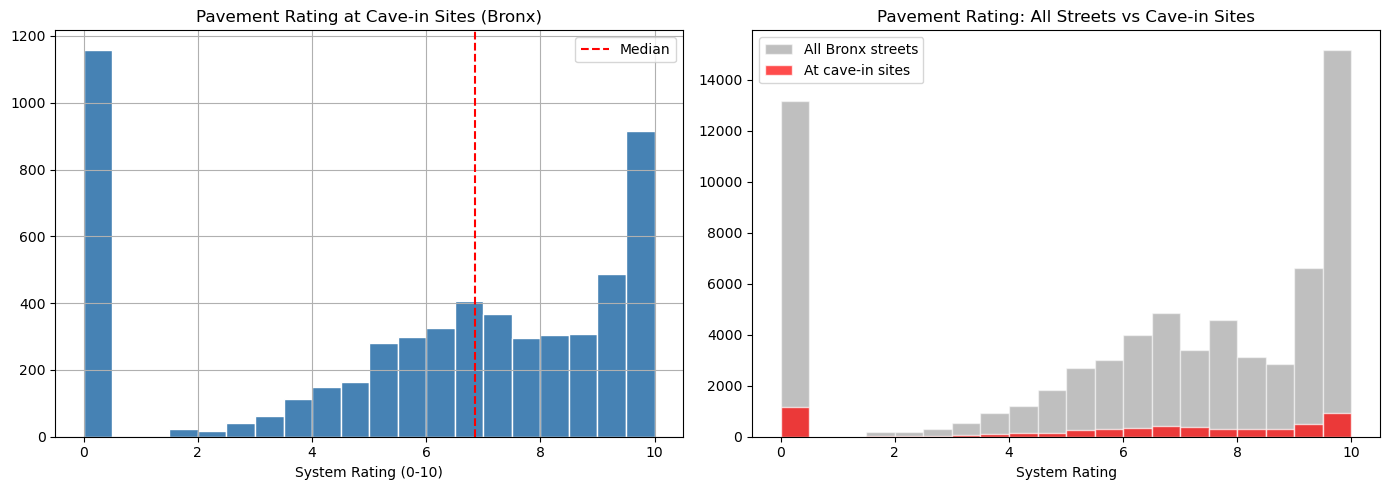

Median rating (all Bronx): 7.15
Median rating (cave-in sites): 6.85


In [12]:
pave_coords = np.radians(df_pave_bronx[['latitude', 'longitude']].values)
pave_tree = cKDTree(pave_coords)
cave_coords_arr = np.radians(df_311[['latitude', 'longitude']].values)
pave_dist, pave_idx = pave_tree.query(cave_coords_arr, k=1)

df_311 = df_311.copy()
df_311['nearest_pavement_rating'] = df_pave_bronx['system_rating'].iloc[pave_idx].values
df_311['nearest_pavement_dist_m'] = pave_dist * 6371000
df_311['nearest_pavement_rating'] = df_311['nearest_pavement_rating'].where(
    df_311['nearest_pavement_dist_m'] < 500, other=np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_311['nearest_pavement_rating'].dropna().hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Pavement Rating at Cave-in Sites (Bronx)')
axes[0].set_xlabel('System Rating (0-10)')
axes[0].axvline(df_311['nearest_pavement_rating'].median(), color='red', linestyle='--', label='Median')
axes[0].legend()

axes[1].hist(df_pave_bronx['system_rating'].dropna(), bins=20, alpha=0.5, color='gray', edgecolor='white', label='All Bronx streets')
axes[1].hist(df_311['nearest_pavement_rating'].dropna(), bins=20, alpha=0.7, color='red', edgecolor='white', label='At cave-in sites')
axes[1].set_title('Pavement Rating: All Streets vs Cave-in Sites')
axes[1].set_xlabel('System Rating')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Median rating (all Bronx): {df_pave_bronx['system_rating'].median():.2f}")
print(f"Median rating (cave-in sites): {df_311['nearest_pavement_rating'].median():.2f}")

## 10. Multi-Layer Risk Heatmap

In [13]:
m4 = folium.Map(location=[40.837, -73.865], zoom_start=12, tiles='CartoDB dark_matter')

fg1 = folium.FeatureGroup(name='Cave-ins').add_to(m4)
HeatMap(df_311[['latitude','longitude']].dropna().values.tolist(),
        radius=12, blur=15, min_opacity=0.3,
        gradient={0.4:'blue',0.7:'orange',1.0:'red'}).add_to(fg1)

fg2 = folium.FeatureGroup(name='Water Main Breaks').add_to(m4)
HeatMap(df_wmb_bronx[['latitude','longitude']].dropna().values.tolist(),
        radius=14, blur=18, min_opacity=0.3,
        gradient={0.4:'green',0.7:'yellow',1.0:'white'}).add_to(fg2)

poor_pave = df_pave_bronx[df_pave_bronx['system_rating'] <= 5].copy()
poor_pave['weight'] = 1 - (poor_pave['system_rating'] / 5)
fg3 = folium.FeatureGroup(name='Poor Pavement (rating <= 5)').add_to(m4)
HeatMap(poor_pave[['latitude','longitude','weight']].dropna().values.tolist(),
        radius=10, blur=12, min_opacity=0.2,
        gradient={0.4:'purple',0.7:'magenta',1.0:'white'}).add_to(fg3)

folium.LayerControl().add_to(m4)
m4.save('heatmap_multi_layer.html')
print('Saved: heatmap_multi_layer.html')
m4

Saved: heatmap_multi_layer.html


## 11. Feature Analysis — Labeled Dataset
Positives = cave-in locations. Negatives = street segment centroids (no cave-in within 150m, no underpasses/overpasses).

In [14]:
# Negatives from pavement segment centroids (real street locations only)
df_pave_neg_pool = df_pave_bronx[['latitude', 'longitude']].dropna().copy()

cave_tree = cKDTree(np.radians(df_311[['latitude', 'longitude']].values))
pool_coords = np.radians(df_pave_neg_pool[['latitude', 'longitude']].values)
dists, _ = cave_tree.query(pool_coords, k=1)
df_pave_neg_pool = df_pave_neg_pool[dists * 6371000 > 150].copy()

n_neg = min(len(df_311) * 2, len(df_pave_neg_pool))
df_neg = df_pave_neg_pool.sample(n=n_neg, random_state=42).copy()
df_neg['label'] = 0

df_pos = df_311[['latitude', 'longitude']].copy()
df_pos['label'] = 1

print(f'Negative pool (street segments): {len(df_pave_neg_pool):,}')
print(f'Positive samples (cave-ins):     {len(df_pos):,}')
print(f'Negative samples drawn:          {len(df_neg):,}')

Negative pool (street segments): 14,197
Positive samples (cave-ins):     49,191
Negative samples drawn:          14,197


## 12. Assign Features to All Samples

In [15]:
def assign_nearest(df_target, df_source, value_col, lat_col='latitude', lon_col='longitude', max_dist_m=2000):
    src = df_source.dropna(subset=[lat_col, lon_col, value_col])
    tree = cKDTree(np.radians(src[[lat_col, lon_col]].values))
    tgt = np.radians(df_target[['latitude', 'longitude']].values)
    dists, idx = tree.query(tgt, k=1)
    vals = src[value_col].iloc[idx].values.astype(float)
    vals[dists * 6371000 > max_dist_m] = np.nan
    return vals

def count_within(df_target, src_df, radius_m=300):
    src = src_df.dropna(subset=['latitude','longitude'])
    src_tree = cKDTree(np.radians(src[['latitude','longitude']].values))
    coords = np.radians(df_target[['latitude','longitude']].values)
    r = radius_m / 6371000
    return np.array([len(src_tree.query_ball_point(c, r)) for c in coords])

for df, label in [(df_pos, 'pos'), (df_neg, 'neg')]:
    df['bedrock_depth']   = assign_nearest(df, df_bedrock, 'depth_ft', max_dist_m=2000)
    df['pavement_rating'] = assign_nearest(df, df_pave_bronx, 'system_rating', max_dist_m=500)
    df['wmb_count_300m']  = count_within(df, df_wmb_bronx)

df_all = pd.concat([df_pos, df_neg], ignore_index=True)
print('Feature assignment complete.')
df_all[['label','bedrock_depth','pavement_rating','wmb_count_300m']].describe()

Feature assignment complete.


,label,bedrock_depth,pavement_rating,wmb_count_300m
count,63388.000000,38709.000000,19915.000000,63388.000000
mean,0.776030,292.123475,6.131594,1.826639
std,0.416905,225.682228,3.558606,3.651190
min,0.000000,3.040000,0.000000,0.000000
25%,1.000000,74.940000,4.380000,0.000000
50%,1.000000,243.240000,7.010000,0.000000
75%,1.000000,429.290000,9.110000,2.000000
max,1.000000,1206.410070,10.000000,32.000000


## 13. Feature Distribution Comparison

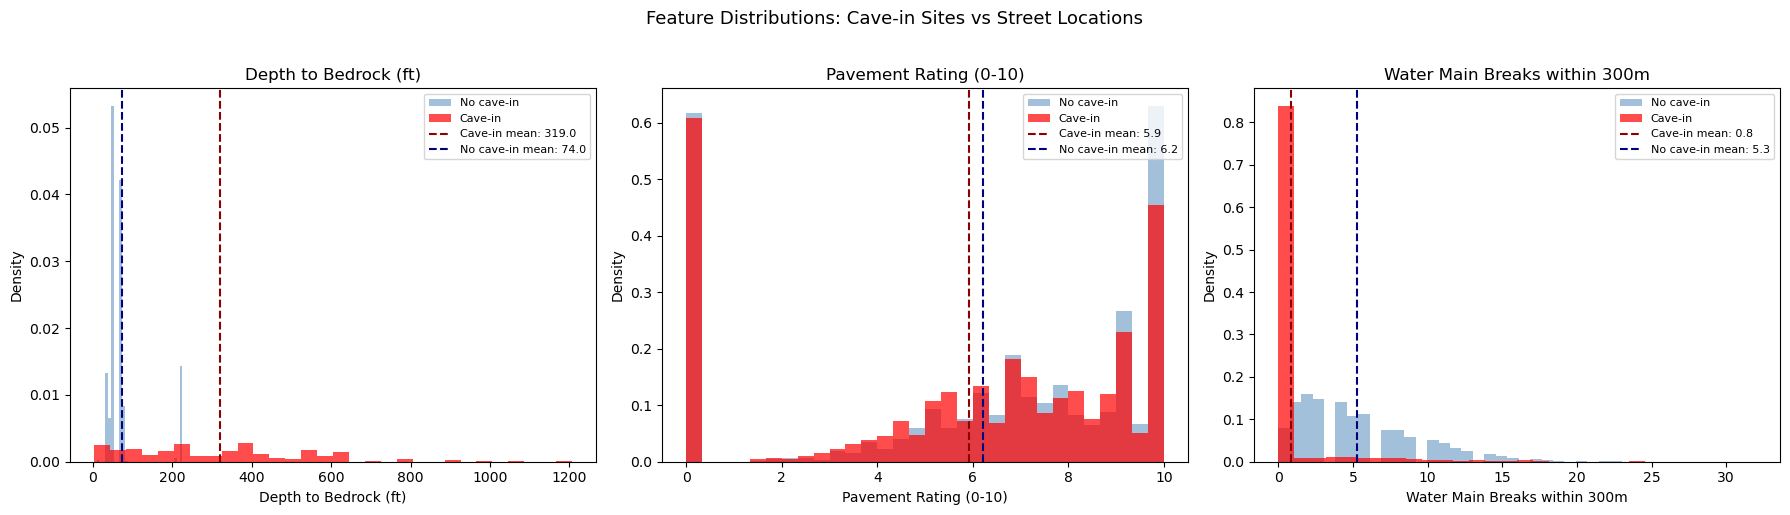

In [16]:
features = {
    'bedrock_depth':   'Depth to Bedrock (ft)',
    'pavement_rating': 'Pavement Rating (0-10)',
    'wmb_count_300m':  'Water Main Breaks within 300m',
}

fig, axes = plt.subplots(1, len(features), figsize=(18, 5))
for ax, (col, label) in zip(axes, features.items()):
    pos_vals = df_all[df_all['label'] == 1][col].dropna()
    neg_vals = df_all[df_all['label'] == 0][col].dropna()
    ax.hist(neg_vals, bins=30, alpha=0.5, color='steelblue', density=True, label='No cave-in')
    ax.hist(pos_vals, bins=30, alpha=0.7, color='red',       density=True, label='Cave-in')
    ax.axvline(pos_vals.mean(), color='darkred', linestyle='--', linewidth=1.5, label=f'Cave-in mean: {pos_vals.mean():.1f}')
    ax.axvline(neg_vals.mean(), color='navy',    linestyle='--', linewidth=1.5, label=f'No cave-in mean: {neg_vals.mean():.1f}')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions: Cave-in Sites vs Street Locations', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 14. Mann-Whitney U Tests

In [ ]:
print(f"{'Feature':<35} {'Cave-in Mean':>14} {'No Cave-in Mean':>16} {'p-value':>10} {'Significant?':>13}")
print('-' * 92)
for col, label in features.items():
    pos_vals = df_all[df_all['label'] == 1][col].dropna()
    neg_vals = df_all[df_all['label'] == 0][col].dropna()
    if len(pos_vals) < 5 or len(neg_vals) < 5:
        print(f'{label:<35} insufficient data')
        continue
    stat, p = stats.mannwhitneyu(pos_vals, neg_vals, alternative='two-sided')
    sig = 'YES ***' if p < 0.001 else ('YES *' if p < 0.05 else 'no')
    print(f'{label:<35} {pos_vals.mean():>14.2f} {neg_vals.mean():>16.2f} {p:>10.4f} {sig:>13}')

## 15. Spatial Block CV + Permutation Importance
The Bronx is divided into a 4x4 grid. Each fold holds out one geographic block entirely, preventing spatial leakage between train and test sets.

In [ ]:
feature_cols = list(features.keys())
df_model = df_all[feature_cols + ['label', 'latitude', 'longitude']].dropna()
X = df_model[feature_cols].values
y = df_model['label'].values
coords = df_model[['latitude', 'longitude']].values

# Build spatial blocks
n_lat, n_lon = 4, 4
lat_bins = np.linspace(coords[:,0].min(), coords[:,0].max(), n_lat + 1)
lon_bins = np.linspace(coords[:,1].min(), coords[:,1].max(), n_lon + 1)
block_ids = (
    np.digitize(coords[:,0], lat_bins[1:-1]) * n_lon +
    np.digitize(coords[:,1], lon_bins[1:-1])
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

spatial_cv_scores = []
for block in np.unique(block_ids):
    test_mask  = block_ids == block
    train_mask = ~test_mask
    if test_mask.sum() < 5 or train_mask.sum() < 5:
        continue
    if len(np.unique(y[test_mask])) < 2:
        continue
    pipe.fit(X[train_mask], y[train_mask])
    proba = pipe.predict_proba(X[test_mask])[:, 1]
    spatial_cv_scores.append(roc_auc_score(y[test_mask], proba))

print(f'Spatial Block CV ROC-AUC: {np.mean(spatial_cv_scores):.3f} (+/- {np.std(spatial_cv_scores):.3f})')
print(f'Blocks evaluated: {len(spatial_cv_scores)}')
print(f'Per-block scores: {[round(s,3) for s in spatial_cv_scores]}')

In [ ]:
# Permutation importance — fit on full data, shuffle each feature 30x
pipe.fit(X, y)
perm = permutation_importance(pipe, X, y, n_repeats=30, random_state=42, scoring='roc_auc')

fig, ax = plt.subplots(figsize=(8, 4))
sorted_idx = perm.importances_mean.argsort()
labels = [list(features.values())[i] for i in sorted_idx]
means  = perm.importances_mean[sorted_idx]
stds   = perm.importances_std[sorted_idx]
ax.barh(labels, means, xerr=stds, color='steelblue', edgecolor='white', capsize=4)
ax.set_xlabel('Drop in ROC-AUC when feature is shuffled')
ax.set_title('Permutation Feature Importance (Spatial Block CV)')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretation:')
for i in sorted_idx[::-1]:
    label = list(features.values())[i]
    m, s = perm.importances_mean[i], perm.importances_std[i]
    verdict = 'useful predictor' if m > 0.01 else 'weak/no signal'
    print(f'  {label:<35} mean drop={m:.3f} +/-{s:.3f}  -> {verdict}')